In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [16]:
# 1. ПІДГОТОВКА ДАНИХ

def load_and_preprocess_data(file_path='WineQT.csv'):

    # Завантаження даних
    df = pd.read_csv(file_path)
    
    # Відокремлення ознак та міток
    X = df.drop('quality', axis=1).values
    y = df['quality'].values
    
    # Перетворення міток у діапазон [0, num_classes-1]
    # Якість вина зазвичай від 3 до 8
    unique_labels = np.unique(y)
    label_mapping = {label: idx for idx, label in enumerate(unique_labels)}
    y = np.array([label_mapping[label] for label in y])
    
    num_classes = len(unique_labels)
    
    # Нормалізація ознак
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    # Розділення на train/val/test (60/20/20)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )
    
    # Конвертація в тензори PyTorch
    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    X_test = torch.FloatTensor(X_test)
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)
    y_test = torch.LongTensor(y_test)
    
    print(f"Розмір тренувальної вибірки: {X_train.shape}")
    print(f"Розмір валідаційної вибірки: {X_val.shape}")
    print(f"Розмір тестової вибірки: {X_test.shape}")
    print(f"Кількість класів: {num_classes}")
    print(f"Розподіл класів (train): {np.bincount(y_train.numpy())}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, num_classes, unique_labels


In [13]:
X_train, X_val, X_test, y_train, y_val, y_test, num_classes, class_names = load_and_preprocess_data()

Розмір тренувальної вибірки: torch.Size([685, 12])
Розмір валідаційної вибірки: torch.Size([229, 12])
Розмір тестової вибірки: torch.Size([229, 12])
Кількість класів: 6
Розподіл класів (train): [  4  20 289 277  86   9]


In [34]:
# 2. ФУНКЦІЇ АКТИВАЦІЇ 

class ActivationFunctions:

    
    @staticmethod
    def relu(x, derivative=False):

        if derivative:
            return (x > 0).float()
        return torch.maximum(torch.zeros_like(x), x)
    
    @staticmethod
    def tanh(x, derivative=False):

        if derivative:
            return 1 - torch.tanh(x)**2
        return torch.tanh(x)
    
    @staticmethod
    def sigmoid(x, derivative=False):

        if derivative:
            sig = torch.sigmoid(x)
            return sig * (1 - sig)
        return torch.sigmoid(x)
    
    @staticmethod
    def softmax(x):

        # Віднімаємо максимум для числової стабільності
        exp_x = torch.exp(x - torch.max(x, dim=0, keepdim=True)[0])
        return exp_x / torch.sum(exp_x, dim=0, keepdim=True)

In [35]:
# 3. ФУНКЦІЯ ВТРАТ 


class LossFunctions:

    @staticmethod
    def categorical_cross_entropy(y_pred, y_true, derivative=False):
   
        batch_size = y_true.shape[0]
        
        if derivative:
            # Оптимізована похідна для softmax + cross_entropy
            grad = y_pred.clone()
            grad[range(batch_size), y_true] -= 1
            return grad / batch_size
        
        # Forward pass: обчислення втрат
        # Додаємо малу константу для уникнення log(0)
        epsilon = 1e-10
        y_pred_clipped = torch.clamp(y_pred, epsilon, 1 - epsilon)
        
        # Вибираємо ймовірності для правильних класів
        correct_confidences = y_pred_clipped[range(batch_size), y_true]
        
        # Обчислюємо втрати
        loss = -torch.log(correct_confidences)
        return torch.mean(loss)

In [36]:
# 4. ВЛАСНА РЕАЛІЗАЦІЯ MLP

class CustomMLP:
  
    
    def __init__(self, layer_sizes, activations, learning_rate=0.01):
 
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.learning_rate = learning_rate
        self.parameters = {}
        self.activation_funcs = ActivationFunctions()
        
        # Ініціалізація ваг методом Xavier (Glorot initialization)
        # Xavier допомагає підтримувати однакову дисперсію на всіх шарах
        for i in range(1, len(layer_sizes)):
            # Xavier: std = sqrt(2 / (fan_in + fan_out))
            std = np.sqrt(2.0 / (layer_sizes[i-1] + layer_sizes[i]))
            
            self.parameters[f'W{i}'] = torch.randn(
                layer_sizes[i], layer_sizes[i-1]
            ) * std
            
            # Зміщення ініціалізуємо нулями
            self.parameters[f'b{i}'] = torch.zeros(layer_sizes[i], 1)
        
        print(f"Ініціалізовано MLP з архітектурою: {layer_sizes}")
        print(f"Функції активації: {activations}")
    
    def forward(self, X, training=True):
      
        # Транспонуємо X 
        cache = {'A0': X.T}
        A = X.T
        
        # Проходимо через всі шари
        for i in range(1, len(self.layer_sizes)):
            # Лінійне перетворення: Z = W·A + b
            Z = self.parameters[f'W{i}'] @ A + self.parameters[f'b{i}']
            
            # Активація (окрім вихідного шару, де використовуємо softmax)
            if i < len(self.layer_sizes) - 1:
                # Приховані шари
                activation = self.activations[i-1]
                if activation == 'relu':
                    A = self.activation_funcs.relu(Z)
                elif activation == 'tanh':
                    A = self.activation_funcs.tanh(Z)
                elif activation == 'sigmoid':
                    A = self.activation_funcs.sigmoid(Z)
            else:
                # Вихідний шар: використовуємо softmax
                A = self.activation_funcs.softmax(Z)
            
            if training:
                cache[f'Z{i}'] = Z
                cache[f'A{i}'] = A
        
        return A.T, cache  # Повертаємо у форматі (batch_size, output_size)
    
    def backward(self, X, y, cache):
       
        batch_size = X.shape[0]
        gradients = {}
        
        # Градієнт для вихідного шару (softmax + cross-entropy)
        # Це спрощена формула: dL/dZ = A - y_one_hot
        A_output = cache[f'A{len(self.layer_sizes)-1}']
        dZ = A_output.clone()
        dZ[y, range(batch_size)] -= 1
        dZ /= batch_size
        
        # Зворотній прохід через шари
        for i in range(len(self.layer_sizes) - 1, 0, -1):
            A_prev = cache[f'A{i-1}']
            
            # Градієнти для ваг та зміщень
            gradients[f'dW{i}'] = dZ @ A_prev.T
            gradients[f'db{i}'] = torch.sum(dZ, dim=1, keepdim=True)
            
            # Якщо не перший шар, продовжуємо backprop
            if i > 1:
                # dA = W^T · dZ
                dA = self.parameters[f'W{i}'].T @ dZ
                
                # dZ = dA * g'(Z), де g' - похідна функції активації
                Z_prev = cache[f'Z{i-1}']
                activation = self.activations[i-2]
                
                if activation == 'relu':
                    dZ = dA * self.activation_funcs.relu(Z_prev, derivative=True)
                elif activation == 'tanh':
                    dZ = dA * self.activation_funcs.tanh(Z_prev, derivative=True)
                elif activation == 'sigmoid':
                    dZ = dA * self.activation_funcs.sigmoid(Z_prev, derivative=True)
        
        # Оновлення параметрів (градієнтний спуск)
        for i in range(1, len(self.layer_sizes)):
            self.parameters[f'W{i}'] -= self.learning_rate * gradients[f'dW{i}']
            self.parameters[f'b{i}'] -= self.learning_rate * gradients[f'db{i}']
    
    def train(self, X_train, y_train, X_val, y_val, epochs=1000, batch_size=32):
      
        history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': []
        }
        
        num_batches = len(X_train) // batch_size
        
        for epoch in range(epochs):
            # Перемішування даних
            indices = torch.randperm(len(X_train))
            X_train_shuffled = X_train[indices]
            y_train_shuffled = y_train[indices]
            
            epoch_loss = 0
            epoch_correct = 0
            epoch_total = 0
            
            # Навчання по батчах
            for batch_idx in range(num_batches):
                start_idx = batch_idx * batch_size
                end_idx = start_idx + batch_size
                
                X_batch = X_train_shuffled[start_idx:end_idx]
                y_batch = y_train_shuffled[start_idx:end_idx]
                
                # Forward pass
                output, cache = self.forward(X_batch, training=True)
                
                # Обчислення втрат
                loss = LossFunctions.categorical_cross_entropy(
                    output, y_batch, derivative=False
                )
                epoch_loss += loss.item()
                
                # Обчислення точності
                predictions = torch.argmax(output, dim=1)
                epoch_correct += (predictions == y_batch).sum().item()
                epoch_total += len(y_batch)
                
                # Backward pass
                self.backward(X_batch, y_batch, cache)
            
            # Середні метрики за епоху
            avg_train_loss = epoch_loss / num_batches
            train_acc = epoch_correct / epoch_total
            
            # Валідація
            with torch.no_grad():
                val_output, _ = self.forward(X_val, training=False)
                val_loss = LossFunctions.categorical_cross_entropy(
                    val_output, y_val, derivative=False
                )
                val_predictions = torch.argmax(val_output, dim=1)
                val_acc = (val_predictions == y_val).float().mean().item()
            
            history['train_loss'].append(avg_train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss.item())
            history['val_acc'].append(val_acc)
            
            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1}/{epochs} - "
                      f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, "
                      f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        return history
    
    def predict(self, X):
        """Передбачення для вхідних даних."""
        output, _ = self.forward(X, training=False)
        return torch.argmax(output, dim=1)


In [37]:
# 5. PYTORCH РЕАЛІЗАЦІЯ ДЛЯ ПОРІВНЯННЯ

class PyTorchMLP(nn.Module):

    
    def __init__(self, input_size, hidden_sizes, output_size, activations):
        super(PyTorchMLP, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Приховані шари
        for hidden_size, activation in zip(hidden_sizes, activations):
            layers.append(nn.Linear(prev_size, hidden_size))
            
            if activation == 'relu':
                layers.append(nn.ReLU())
            elif activation == 'tanh':
                layers.append(nn.Tanh())
            elif activation == 'sigmoid':
                layers.append(nn.Sigmoid())
            
            prev_size = hidden_size
        
        # Вихідний шар
        layers.append(nn.Linear(prev_size, output_size))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)


def train_pytorch_model(model, X_train, y_train, X_val, y_val, 
                       epochs=1000, batch_size=32, learning_rate=0.01):
  
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    num_batches = len(X_train) // batch_size
    
    for epoch in range(epochs):
        model.train()
        
        # Перемішування даних
        indices = torch.randperm(len(X_train))
        X_train_shuffled = X_train[indices]
        y_train_shuffled = y_train[indices]
        
        epoch_loss = 0
        epoch_correct = 0
        epoch_total = 0
        
        for batch_idx in range(num_batches):
            start_idx = batch_idx * batch_size
            end_idx = start_idx + batch_size
            
            X_batch = X_train_shuffled[start_idx:end_idx]
            y_batch = y_train_shuffled[start_idx:end_idx]
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            predictions = torch.argmax(outputs, dim=1)
            epoch_correct += (predictions == y_batch).sum().item()
            epoch_total += len(y_batch)
        
        avg_train_loss = epoch_loss / num_batches
        train_acc = epoch_correct / epoch_total
        
        # Валідація
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)
            val_predictions = torch.argmax(val_outputs, dim=1)
            val_acc = (val_predictions == y_val).float().mean().item()
        
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss.item())
        history['val_acc'].append(val_acc)
        
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs} - "
                  f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    return history


In [38]:
# 6. ВІЗУАЛІЗАЦІЯ ТА АНАЛІЗ

def plot_training_history(history_custom, history_pytorch):
   
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Train Loss
    axes[0, 0].plot(history_custom['train_loss'], label='Custom MLP', linewidth=2)
    axes[0, 0].plot(history_pytorch['train_loss'], label='PyTorch MLP', linewidth=2, alpha=0.7)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Validation Loss
    axes[0, 1].plot(history_custom['val_loss'], label='Custom MLP', linewidth=2)
    axes[0, 1].plot(history_pytorch['val_loss'], label='PyTorch MLP', linewidth=2, alpha=0.7)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('Validation Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Train Accuracy
    axes[1, 0].plot(history_custom['train_acc'], label='Custom MLP', linewidth=2)
    axes[1, 0].plot(history_pytorch['train_acc'], label='PyTorch MLP', linewidth=2, alpha=0.7)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].set_title('Training Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Validation Accuracy
    axes[1, 1].plot(history_custom['val_acc'], label='Custom MLP', linewidth=2)
    axes[1, 1].plot(history_pytorch['val_acc'], label='PyTorch MLP', linewidth=2, alpha=0.7)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].set_title('Validation Accuracy')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_confusion_matrices(y_true, y_pred_custom, y_pred_pytorch, class_names):
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Custom MLP
    cm_custom = confusion_matrix(y_true, y_pred_custom)
    sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Custom MLP Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    
    # PyTorch MLP
    cm_pytorch = confusion_matrix(y_true, y_pred_pytorch)
    sns.heatmap(cm_pytorch, annot=True, fmt='d', cmap='Greens', 
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('PyTorch MLP Confusion Matrix')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    
    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()


def print_comparison_report(y_true, y_pred_custom, y_pred_pytorch, class_names):
    
    print("\n" + "="*70)
    print("ПОРІВНЯЛЬНИЙ АНАЛІЗ МОДЕЛЕЙ")
    print("="*70)
    
    acc_custom = accuracy_score(y_true, y_pred_custom)
    acc_pytorch = accuracy_score(y_true, y_pred_pytorch)
    
    print(f"\nТочність на тестовій вибірці:")
    print(f"  Custom MLP:  {acc_custom:.4f} ({acc_custom*100:.2f}%)")
    print(f"  PyTorch MLP: {acc_pytorch:.4f} ({acc_pytorch*100:.2f}%)")
    print(f"  Різниця:     {abs(acc_custom - acc_pytorch):.4f} ({abs(acc_custom - acc_pytorch)*100:.2f}%)")
    
    print("\n" + "-"*70)
    print("Custom MLP:")
    print("-"*70)
    print(classification_report(y_true, y_pred_custom, target_names=class_names))
    
    print("\n" + "-"*70)
    print("PyTorch MLP:")
    print("-"*70)
    print(classification_report(y_true, y_pred_pytorch, target_names=class_names))

In [39]:
# 7. ЗАПУСК


def main():
  
    print("="*70)
    print("ЛАБОРАТОРНА РОБОТА 5: РЕАЛІЗАЦІЯ MLP В PYTORCH")
    print("="*70)
    
    # 1. Завантаження та підготовка даних
    print("\n1. Завантаження та підготовка даних...")
    X_train, X_val, X_test, y_train, y_val, y_test, num_classes, class_names = \
        load_and_preprocess_data()
    
    input_size = X_train.shape[1]
    
    # 2. Визначення архітектури
    print("\n2. Визначення архітектури мережі...")
    hidden_sizes = [64, 32]  # Два приховані шари
    activations = ['relu', 'relu']  # Функції активації для прихованих шарів
    layer_sizes = [input_size] + hidden_sizes + [num_classes]
    
    print(f"Архітектура: {layer_sizes}")
    print(f"Активації: {activations}")
    
    # 3. Навчання власної реалізації
    print("\n3. Навчання Custom MLP...")
    print("-"*70)
    custom_mlp = CustomMLP(
        layer_sizes=layer_sizes,
        activations=activations,
        learning_rate=0.01
    )
    
    history_custom = custom_mlp.train(
        X_train, y_train, X_val, y_val,
        epochs=500,
        batch_size=32
    )
    
    # 4. Навчання PyTorch реалізації
    print("\n4. Навчання PyTorch MLP...")
    print("-"*70)
    pytorch_mlp = PyTorchMLP(
        input_size=input_size,
        hidden_sizes=hidden_sizes,
        output_size=num_classes,
        activations=activations
    )
    
    history_pytorch = train_pytorch_model(
        pytorch_mlp, X_train, y_train, X_val, y_val,
        epochs=500,
        batch_size=32,
        learning_rate=0.01
    )
    
    # 5. Оцінка на тестовій вибірці
    print("\n5. Оцінка моделей на тестовій вибірці...")
    y_pred_custom = custom_mlp.predict(X_test).numpy()
    
    pytorch_mlp.eval()
    with torch.no_grad():
        y_pred_pytorch = torch.argmax(pytorch_mlp(X_test), dim=1).numpy()
    
    y_true = y_test.numpy()
    
    # 6. Візуалізація результатів
    print("\n6. Візуалізація результатів...")
    plot_training_history(history_custom, history_pytorch)
    plot_confusion_matrices(y_true, y_pred_custom, y_pred_pytorch, 
                           [str(c) for c in class_names])
    
    # 7. Детальний звіт
    print_comparison_report(y_true, y_pred_custom, y_pred_pytorch,
                           [str(c) for c in class_names])
    


ЛАБОРАТОРНА РОБОТА 5: РЕАЛІЗАЦІЯ MLP В PYTORCH

1. Завантаження та підготовка даних...
Розмір тренувальної вибірки: torch.Size([685, 12])
Розмір валідаційної вибірки: torch.Size([229, 12])
Розмір тестової вибірки: torch.Size([229, 12])
Кількість класів: 6
Розподіл класів (train): [  4  20 289 277  86   9]

2. Визначення архітектури мережі...
Архітектура: [12, 64, 32, 6]
Активації: ['relu', 'relu']

3. Навчання Custom MLP...
----------------------------------------------------------------------
Ініціалізовано MLP з архітектурою: [12, 64, 32, 6]
Функції активації: ['relu', 'relu']
Epoch 100/500 - Train Loss: 0.8444, Train Acc: 0.6324, Val Loss: 0.9089, Val Acc: 0.6681
Epoch 200/500 - Train Loss: 0.7571, Train Acc: 0.6905, Val Loss: 0.9020, Val Acc: 0.6376
Epoch 300/500 - Train Loss: 0.6603, Train Acc: 0.7366, Val Loss: 0.9173, Val Acc: 0.6463
Epoch 400/500 - Train Loss: 0.5783, Train Acc: 0.7708, Val Loss: 0.9579, Val Acc: 0.6594
Epoch 500/500 - Train Loss: 0.4917, Train Acc: 0.8229, Val

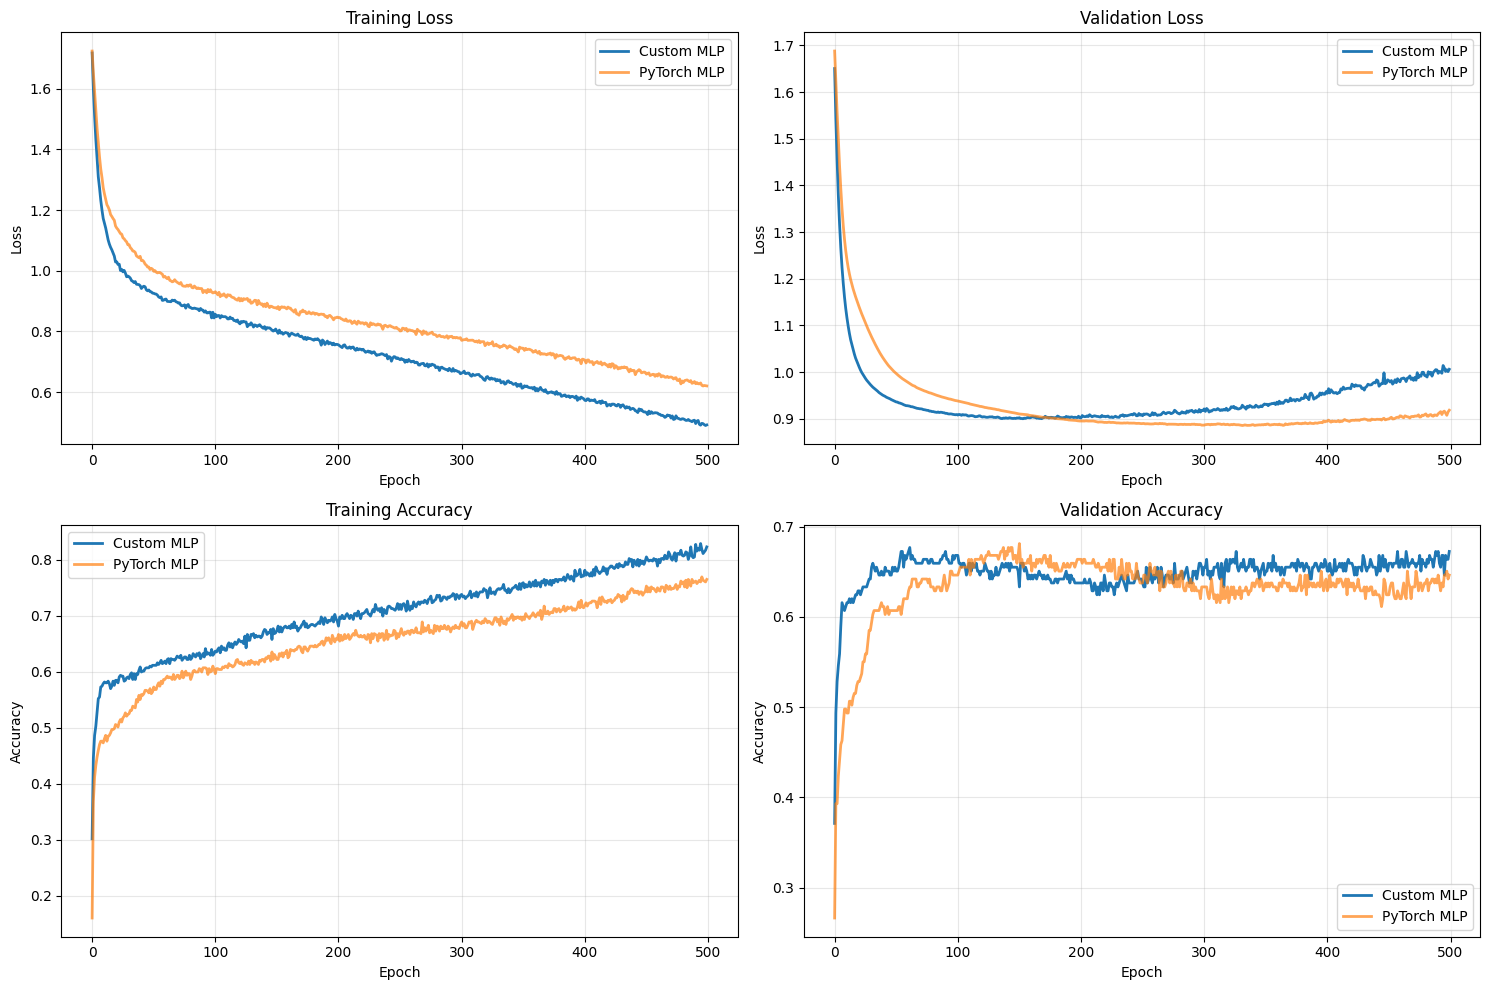

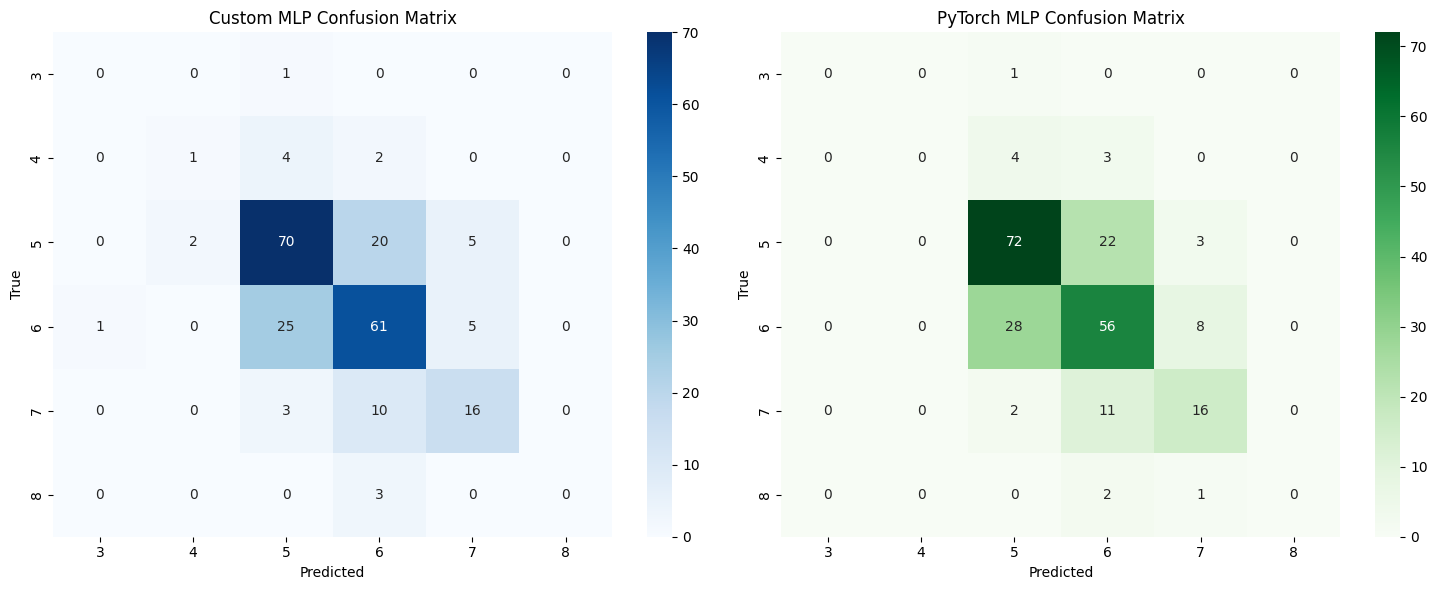


ПОРІВНЯЛЬНИЙ АНАЛІЗ МОДЕЛЕЙ

Точність на тестовій вибірці:
  Custom MLP:  0.6463 (64.63%)
  PyTorch MLP: 0.6288 (62.88%)
  Різниця:     0.0175 (1.75%)

----------------------------------------------------------------------
Custom MLP:
----------------------------------------------------------------------
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.33      0.14      0.20         7
           5       0.68      0.72      0.70        97
           6       0.64      0.66      0.65        92
           7       0.62      0.55      0.58        29
           8       0.00      0.00      0.00         3

    accuracy                           0.65       229
   macro avg       0.38      0.35      0.36       229
weighted avg       0.63      0.65      0.64       229


----------------------------------------------------------------------
PyTorch MLP:
-----------------------------------------------------------------

c:\Users\Tania\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Tania\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Tania\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [40]:
main()

In [41]:
# 8. ВІДПОВІДІ НА ТЕОРЕТИЧНІ ПИТАННЯ

def theoretical_questions():

    print("\n" + "="*70)
    print("ВІДПОВІДІ НА ТЕОРЕТИЧНІ ПИТАННЯ")
    print("="*70)
    
    print("\n" + "-"*70)
    print("ПИТАННЯ 1: Похідна комбінації Softmax + Cross-Entropy")
    print("-"*70)
    print("""
ДОВЕДЕННЯ:

Нехай:
- z_i - логіти (вихід останнього шару без активації)
- y_pred_i = softmax(z_i) = exp(z_i) / Σ exp(z_j)
- L = -Σ y_true_i * log(y_pred_i)  (Cross-Entropy)

Для багатокласової класифікації y_true - one-hot вектор:
y_true = [0, 0, ..., 1, ..., 0], де 1 на позиції правильного класу k.

Тоді: L = -log(y_pred_k) = -log(exp(z_k) / Σ exp(z_j))
           = -z_k + log(Σ exp(z_j))

Обчислюємо похідну ∂L/∂z_i:

Випадок 1: i = k (правильний клас)
∂L/∂z_k = -1 + exp(z_k) / Σ exp(z_j) = -1 + y_pred_k = y_pred_k - 1

Випадок 2: i ≠ k (неправильний клас)
∂L/∂z_i = 0 + exp(z_i) / Σ exp(z_j) = y_pred_i = y_pred_i - 0

Об'єднуючи обидва випадки:
∂L/∂z_i = y_pred_i - y_true_i


ДЕТАЛЬНЕ ДОВЕДЕННЯ через матрицю Якобі:

Для softmax:
∂y_pred_i/∂z_j = y_pred_i * (δ_ij - y_pred_j)

де δ_ij - дельта Кронекера (1 якщо i=j, 0 інакше).

Для cross-entropy:
∂L/∂y_pred_i = -y_true_i / y_pred_i

За ланцюговим правилом:
∂L/∂z_j = Σ_i (∂L/∂y_pred_i) * (∂y_pred_i/∂z_j)
        = Σ_i (-y_true_i / y_pred_i) * y_pred_i * (δ_ij - y_pred_j)
        = -Σ_i y_true_i * (δ_ij - y_pred_j)
        = -y_true_j + y_pred_j * Σ_i y_true_i
        = -y_true_j + y_pred_j * 1  (оскільки Σ y_true_i = 1)
        = y_pred_j - y_true_j

Ми отримали просту векторну різницю
    """)
    
    print("\n" + "-"*70)
    print("ПИТАННЯ 2: Аналіз зміни градієнтів у глибоких мережах")
    print("-"*70)
    print("""
Розглянемо мережу з 5 шарами з ReLU активацією.

Похідна ReLU:
- f'(x) = 1, якщо x > 0
- f'(x) = 0, якщо x ≤ 0

За ланцюговим правилом градієнт для першого шару:
∂L/∂W₁ = ∂L/∂z₅ · ∂z₅/∂a₄ · ∂a₄/∂z₄ · ... · ∂z₂/∂a₁ · ∂a₁/∂z₁ · ∂z₁/∂W₁

Кожен член ∂aᵢ/∂zᵢ = f'(zᵢ) = {0 або 1} для ReLU.

ЧАСТИНА А: Якщо 60% нейронів мають від'ємні значення:

Ймовірність проходження градієнта через один шар = 40% = 0.4
Ймовірність проходження через 4 шари (для досягнення першого шару) = 0.4⁴ = 0.0256

Після 100 ітерацій:
- ~97.44% градієнтів будуть обнулені ("мертві нейрони")
- Перший шар майже не навчатиметься
- Це проблема "dying ReLU"

МАТЕМАТИЧНИЙ АНАЛІЗ:

Для N шарів з долею активних нейронів p:
P(градієнт досягає шару 1) = p^(N-1)

У нашому випадку:
P = 0.4⁴ = 0.0256 = 2.56%

Це означає, що в середньому лише 2.56% прикладів у батчі призведуть до 
оновлення ваг першого шару!

Через 100 ітерацій з batch_size=32:
Очікувана кількість оновлень ≈ 100 * 32 * 0.0256 ≈ 82 оновлення
порівняно з 3200 оновленнями для останнього шару.

ЧАСТИНА Б: Максимальне значення градієнта:

Якщо всі нейрони активні (найкращий випадок), f'(z) = 1 для всіх:

∂L/∂W₁ ∝ ∏ᵢ₌₂ᴺ Wᵢ

Для N шарів максимальний градієнт ~ (max(W))^(N-1)

Якщо ваги ініціалізовані правильно (наприклад, Xavier):
- E[W] ~ 1/√n
- Градієнт може експоненційно зростати або зменшуватися

ПРИКЛАД:

Припустимо ||W|| ≈ 1 для кожного шару

Максимальний градієнт:
||∂L/∂W₁|| ≤ ||∂L/∂z₅|| · ||W₅|| · ||W₄|| · ||W₃|| · ||W₂||

Якщо ||Wᵢ|| = 1.2 (трохи більше 1):
||∂L/∂W₁|| ≤ ||∂L/∂z₅|| · (1.2)⁴ ≈ ||∂L/∂z₅|| · 2.07

Якщо ||Wᵢ|| = 0.8 (трохи менше 1):
||∂L/∂W₁|| ≤ ||∂L/∂z₅|| · (0.8)⁴ ≈ ||∂L/∂z₅|| · 0.41

Навіть невелике відхилення від ||W|| = 1 призводить до 
експоненційного зростання або зникнення градієнтів!

РІШЕННЯ проблеми:
1. Batch Normalization - стабілізує активації
2. Residual connections (ResNet) - пряме проходження градієнтів
3. Leaky ReLU - f'(x) = α для x < 0 (де α = 0.01)
4. Правильна ініціалізація (Xavier, He initialization)
5. Gradient clipping - обмеження максимального значення градієнта

    """)
    
    print("\n" + "-"*70)
    print("ПИТАННЯ 3: Умовність матричних операцій у backpropagation")
    print("-"*70)
    print("""
ВИВЕДЕННЯ ФОРМУЛИ ДЛЯ ГРАДІЄНТА dW:

Дано: Z = WX + b
де:
- W: (n_out, n_in) - матриця ваг
- X: (n_in, m) - матриця входів (m прикладів)
- Z: (n_out, m) - матриця виходів

Функція втрат: L = L(Z)

Нам потрібно знайти: ∂L/∂W

КРОК 1: Застосування ланцюгового правила

∂L/∂W = ∂L/∂Z · ∂Z/∂W

Маємо: ∂L/∂Z = dZ (розмір: n_out × m)

КРОК 2: Обчислення ∂Z/∂W

Z_ij = Σₖ W_ik · X_kj + b_i

Розглянемо як впливає один елемент W_pq на один елемент Z_ij:

∂Z_ij/∂W_pq = X_qj, якщо i=p та k=q; інакше 0

Це означає, що W_pq впливає тільки на p-й рядок Z, і коефіцієнт 
впливу дорівнює відповідному елементу X.

КРОК 3: Агрегація по всім прикладам

∂L/∂W_pq = Σⱼ₌₁ᵐ (∂L/∂Z_pj) · (∂Z_pj/∂W_pq)
         = Σⱼ₌₁ᵐ dZ_pj · X_qj
         = (dZ @ X^T)_pq

КРОК 4: Усереднення по батчу

dW = (1/m) · dZ @ X^T

ПЕРЕВІРКА РОЗМІРНОСТЕЙ:
- dZ: (n_out, m)
- X^T: (m, n_in)
- dZ @ X^T: (n_out, m) @ (m, n_in) = (n_out, n_in) ✓

Це співпадає з розміром W

dW_ij показує, як зміна ваги між входом j та виходом i
впливає на втрати. Це залежить від:
1. Наскільки помилковий вихід i (це dZ_i)
2. Наскільки активний вхід j (це X_j)

Тому: dW_ij = (1/m) · Σ_samples dZ_i · X_j
            = (1/m) · (dZ · X^T)_ij

ПРАКТИЧНЕ ЗНАЧЕННЯ:

Ця формула є фундаментальною для backpropagation:
1. Дозволяє ефективно обчислювати градієнти
2. Використовує векторизовані операції
3. Легко реалізується на GPU
4. Узагальнюється на довільну кількість шарів
    """)
    
    print("\n" + "-"*70)
    print("ПИТАННЯ 4*: Аналіз власних значень гессіана")
    print("-"*70)
    print("""
Розглянемо просту двошарову мережу:
- Вхідний шар: x ∈ ℝⁿ
- Прихований шар: h = σ(W₁x + b₁), де h ∈ ℝᵐ
- Вихідний шар: y = W₂h + b₂

Функція втрат: L = (1/2)||y - t||²  

ЧАСТИНА А: Матриця Гессіана для W₁

Повна матриця Гессіана має розмір (m·n × m·n) і важка для аналізу.
Розглянемо спрощений випадок для одного елемента W₁ᵢⱼ:

∂L/∂W₁ᵢⱼ = ∂L/∂h · ∂h/∂z · ∂z/∂W₁ᵢⱼ
         = (W₂^T · (y-t)) ⊙ σ'(z) · xⱼ

∂²L/∂W₁ᵢⱼ² містить:
1. σ''(z) - друга похідна активації
2. Квадрати елементів W₂
3. Вхідні дані x

ЗАГАЛЬНА ФОРМА ГЕССІАНА:

H = ∂²L/∂W₁²

Для лінійного випадку (σ(z) = z):
H ≈ (1/m) · Σ_samples (X @ X^T) ⊗ (W₂^T @ W₂)

де ⊗ - кронекерів добуток.

Для нелінійних активацій:
H ≈ (1/m) · Σ_samples (X @ X^T) ⊗ (W₂^T @ W₂ @ diag(σ'(z)²))

ЧАСТИНА Б: Зв'язок власних значень зі швидкістю збіжності

Швидкість збіжності градієнтного спуску залежить від condition number:
κ(H) = λ_max / λ_min

де λ_max, λ_min - максимальне та мінімальне власні значення.

1. Якщо κ(H) велике (погано обумовлена задача):
   - Градієнтний спуск повільно сходиться
   - Потрібна мала швидкість навчання
   - Траєкторія зигзагоподібна
   
   Кількість ітерацій для збіжності: O(κ(H) · log(1/ε))

2. Якщо κ(H) близьке до 1 (добре обумовлена):
   - Швидка збіжність
   - Можна використовувати більшу швидкість навчання
   
   Кількість ітерацій: O(log(1/ε))

АНАЛІЗ ГРАДІЄНТНОГО СПУСКУ:

Оновлення: W_{t+1} = W_t - η · ∇L(W_t)

Швидкість збіжності в напрямку власного вектора v_i з власним значенням λ_i:
|error|_{t+1} = |1 - η·λ_i| · |error|_t

Оптимальна швидкість навчання: η* = 2/(λ_max + λ_min)

При η = η*:
- Найгірша швидкість збіжності: |1 - η*·λ_min| = (κ-1)/(κ+1)
- Кожна ітерація зменшує помилку в ((κ-1)/(κ+1)) разів

Для κ = 100:
((κ-1)/(κ+1)) = 99/101 ≈ 0.98
Потрібно ~230 ітерацій для зменшення помилки в 100 разів.

Для κ = 2:
((κ-1)/(κ+1)) = 1/3 ≈ 0.33
Потрібно ~5 ітерацій для зменшення помилки в 100 разів.

ЧАСТИНА В: Проблема зникаючих градієнтів

У глибоких мережах:
H ∝ ∏ᵢ (Wᵢ^T · Wᵢ · diag(σ'(zᵢ)))

Якщо σ'(z) < 1 для більшості z (наприклад, sigmoid, tanh):
- Власні значення H → 0 експоненційно
- λ_min → 0 дуже швидко
- Градієнти зникають
    """)
    
